In [3]:
# pip install wordcloud

In [3]:
from elasticsearch import Elasticsearch
import pandas as pd
import json
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt
import warnings
import urllib3
import time
import requests
import numpy as np
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress only InsecureRequestWarning from urllib3 (for verify_certs=False)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# === API Parameter ===
api_url = "http://localhost:9090/api/youtubeelectionapi"

# === Define two ranges to avoid 10,000 limit ===
ranges = [
    {"start": "2024-03-01", "end": "2025-03-20"},
    {"start": "2025-03-21", "end": "2026-01-01"}
]

# === Fetch & Combine ===
all_data = []

for i, params in enumerate(ranges):
    response = requests.get(api_url, params=params)
    if response.status_code == 200:
        json_data = response.json()
        results = json_data.get("data", [])
        print(f"[OK] Retrieved {len(results)} documents from range {i+1}")
        all_data.append(pd.DataFrame(results))
    else:
        print(f"[X] Request {i+1} failed with status code {response.status_code}")

# === Combine & Clean ===
if all_data:
    yte_df_raw = pd.concat(all_data, ignore_index=True)
    print(f"[✓] Combined total: {len(yte_df_raw)} rows.")
    display(yte_df_raw.columns)
else:
    print("[X] No data retrieved from any range.")

[OK] Retrieved 3424 documents from range 1
[OK] Retrieved 9557 documents from range 2
[✓] Combined total: 12981 rows.


Index(['snippet', 'search_prompt', 'kind', 'etag', 'id', 'contentDetails',
       'statistics'],
      dtype='object')

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import time

# Normalize raw data
yte_df = pd.json_normalize(yte_df_raw.to_dict(orient='records'))

# Ensure numeric types for relevant fields
for field in ['statistics.viewCount', 'statistics.likeCount', 'statistics.commentCount', 'statistics.favoriteCount']:
    yte_df[field] = yte_df[field].astype(float)

# Parse and localize datetime
yte_df['snippet.publishedAt'] = pd.to_datetime(yte_df['snippet.publishedAt'], utc=True)
yte_df['published_melbourne'] = yte_df['snippet.publishedAt'].dt.tz_convert('Australia/Melbourne')

# Calculate hours since posted using datetime difference
now = pd.Timestamp.now(tz='UTC')
yte_df['hours_since_post'] = (now - yte_df['snippet.publishedAt']).dt.total_seconds() / 3600

# Compute raw weighted score
yte_df['raw_score'] = (
    yte_df['statistics.viewCount'] * 0.5 +
    yte_df['statistics.likeCount'] * 1.0 +
    yte_df['statistics.commentCount'] * 1.5 +
    yte_df['statistics.favoriteCount'] * 1.2
)

# Exponential decay (freshness factor)
yte_df['decay'] = np.exp(-0.05 * yte_df['hours_since_post'] / 24)

# Hotness score = raw * decay
yte_df['score1'] = yte_df['raw_score'] * yte_df['decay']

# Engagement score per view
yte_df['statistics.viewCount'] = yte_df['statistics.viewCount'].replace(0, 1)  # Avoid div-by-zero
yte_df['score2'] = (
    (yte_df['statistics.likeCount'] / yte_df['statistics.viewCount']) +
    2 * (yte_df['statistics.commentCount'] / yte_df['statistics.viewCount']) +
    3 * (yte_df['statistics.favoriteCount'] / yte_df['statistics.viewCount'])
) * 100

# Clean up invalid values
yte_df[['score1', 'score2']] = yte_df[['score1', 'score2']].replace([np.inf, -np.inf], np.nan).fillna(0)



# Scale to [1, 100]
def clip_and_scale(series, feature_range=(1, 100)):
    lower = series.quantile(0.05)
    upper = series.quantile(0.95)
    clipped = series.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

def log_clip_scale(series, feature_range=(1, 100)):
    log_vals = np.log1p(series)  # log(1 + x) 防止 log(0)
    lower = log_vals.quantile(0.05)
    upper = log_vals.quantile(0.95)
    clipped = log_vals.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

yte_df['score1_scaled'] = log_clip_scale(yte_df['score1'])
# score1_log = np.log1p(yte_df['score1'])
# yte_df['score1_scaled'] = scaler.fit_transform(score1_log.values.reshape(-1, 1))
yte_df['score2_scaled'] = clip_and_scale(yte_df['score2'])

# Optional: print info
print("[OK] DataFrame processed. Available columns:")
print(yte_df.columns.tolist())
yte_df.head()


[OK] DataFrame processed. Available columns:
['search_prompt', 'kind', 'etag', 'id', 'snippet.publishedAt', 'snippet.description', 'snippet.title', 'snippet.channelId', 'snippet.categoryId', 'snippet.channelTitle', 'snippet.tags', 'snippet.liveBroadcastContent', 'contentDetails.duration', 'contentDetails.definition', 'contentDetails.dimension', 'statistics.likeCount', 'statistics.viewCount', 'statistics.favoriteCount', 'statistics.commentCount', 'published_melbourne', 'hours_since_post', 'raw_score', 'decay', 'score1', 'score2', 'score1_scaled', 'score2_scaled']


,search_prompt,kind,etag,id,snippet.publishedAt,snippet.description,snippet.title,snippet.channelId,snippet.categoryId,snippet.channelTitle,snippet.tags,snippet.liveBroadcastContent,contentDetails.duration,contentDetails.definition,contentDetails.dimension,statistics.likeCount,statistics.viewCount,statistics.favoriteCount,statistics.commentCount,published_melbourne,hours_since_post,raw_score,decay,score1,score2,score1_scaled,score2_scaled
0,australia election,youtube#video,hIP9z_zhkxSmlfO5UVoXA7pB8WI,9LkLBQ8qHL4,2024-11-01 02:11:16+00:00,Sky News host Rita Panahi reacts to Kamala Harris and Tim Walz's horror week as the presidential election nears.,Lefties losing it: Kamala Harris and Tim Walz campaign falters at finish line,UCO0akufu9MOzyz3nvGIXAAw,25,Sky News Australia,"[6364060795112, fb, msn, opinion, ritapanahi, yt]",none,PT26M23S,hd,2d,19518.0,544261.0,0.0,3764.0,2024-11-01 13:11:16+11:00,4735.407590,297294.5,0.000052,15.441305,4.969307,30.502772,32.443326
1,australia election,youtube#video,VSSzqeGQevLD9mL3DfuMZmteP6E,8LbmwgL-_Pg,2024-11-01 02:36:07+00:00,#news #video #australia #world #youtube #subscribe #electoralcollege #uselections2024 \n\nSubscribe to our YouTube channel:\nhttps://www.youtube.com/c/smh\nSubscribe to our journalism:\nhttps://subscribe.smh.com.au/\nhttps://subscribe.theage.com.au/\nListen to our podcasts:\nhttps://podcasts.smh.com.au/\nhttps://podcasts.theage.com.au/,How does the Electoral College work?,UCi-nUi67HVFEtpaFsjRj_NA,25,The Sydney Morning Herald and The Age,NaN,none,PT48S,hd,2d,19.0,896.0,0.0,0.0,2024-11-01 13:36:07+11:00,4734.993424,467.0,0.000052,0.024277,2.120536,1.252759,14.417705
2,australia election,youtube#video,sU4mtObQmFO2zs6wIVKQJU1BCds,6tKHnK4qvNQ,2024-11-01 02:58:38+00:00,"KPMG Australia Partner and Chief Economist Dr Brendan Rynne has discussed the economic implications the US election outcome could have on Australia's economy. \n\n“I suspect if Vice President Harris wins the presidency, it will be more of the same, and that will be a continuation of the base cuts,” Mr Rynne said.\n\n“What we know is that former president Trump has argued that he will add some protectionist measures on with regards to the US trade.”",Analysis: US election outcome could cause implications for Australia’s economy,UCO0akufu9MOzyz3nvGIXAAw,25,Sky News Australia,"[6364064259112, business, fb, finance, msn, yt]",none,PT3M36S,hd,2d,36.0,2971.0,0.0,36.0,2024-11-01 13:58:38+11:00,4734.618146,1575.5,0.000052,0.081965,3.635140,1.830132,24.001373
3,australia election,youtube#video,XKzHjyTqXLa4uOYj9MXK1IipNKw,wel9fwHYd8s,2024-11-01 04:06:21+00:00,"With the upcoming US elections, let's talk about some of the differences in elections between America and Australia. From the date of the the election, to the controversial US Electoral College, to the presidential terms and democracy sausages, let's chat about some of the differences.\n\nPlease stay respectful in the comments.\n\nFor Business Inquiries, please contact me at: kindaaustralian@gmail.com\nWant to send me something? Send to: Kaitlyn Amanda, PO Box 569, Blacktown NSW 2148, Australia \n\nFILMING EQUIPMENT: Filming on Canon EOS M50 (mine is Mark I which is discontinued) https://amzn.to/3shf3IS \nRing Light: https://amzn.to/3gnMrrE \nExternal Hard Drive: https://amzn.to/3Lf0ePx \n128 GB SD Card: https://amzn.to/34BLBVz \n\nUnder the Copyright Disclaimer Section 107 of the Copyright Act 1976 (United States) and The Copyright Act 1968 (Australia) allowance is made for ""fair use"" for purposes such as criticism, comment, news reporting, teaching, scholarship, and research. Fair use is a use permitted by copyright statute that might otherwise be infringing. Non-profit, educational or personal use tips the balance in favor of fair use.\n\nLinks in this description may be affiliate links from which I receive a small commission at no additional cost to the buyer.\n\nWe would like to acknowledge the Darug Nation, the traditional custodians of this land we work o

In [5]:
import ipywidgets as widgets

# Get min and max dates in local (Melbourne) time
start_date_actual = yte_df['published_melbourne'].min().date()
end_date_actual = yte_df['published_melbourne'].max().date()

# Generate full date range list for slider
date_range = pd.date_range(start=start_date_actual, end=end_date_actual, freq='D')
date_slider = widgets.SelectionRangeSlider(
    options=[d.strftime("%Y-%m-%d") for d in date_range],
    index=(0, len(date_range) - 1),
    description='Date Range:',
    orientation='horizontal',
    layout={'width': '100%'}
)

# Frequency resolution dropdown
resolution = widgets.Dropdown(
    options=[('Hourly', 'H'), ('Every 3 Hours', '3H'), ('Daily', 'D'), ('Weekly', 'W')],
    value='H',
    description='Resolution:'
)

# Combine controls into a UI layout
ui = widgets.VBox([date_slider, resolution])

# Plotting function triggered by widget updates
def update_all_plots(date_range, freq):
    start_str, end_str = date_range
    # Localize start and end to Melbourne timezone to match the DataFrame
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")


    # Filter DataFrame based on selected date range
    yte_df_filtered = yte_df[(yte_df['published_melbourne'] >= start) & (yte_df['published_melbourne'] <= end)]

    if yte_df_filtered.empty:
        print("No data for selected range.")
        return

    # Set time column as index for resampling
    yte_df_tmp = yte_df_filtered.set_index('published_melbourne')

    # Resample metrics
    resampled_count = yte_df_tmp.resample(freq).size()
    resampled_views = yte_df_tmp['statistics.viewCount'].resample(freq).sum()
    resampled_score1 = yte_df_tmp['score1'].resample(freq).mean()
    resampled_score2 = yte_df_tmp['score2'].resample(freq).mean()

    # Create subplots
    fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    axs[0].plot(resampled_count.index, resampled_count.values, marker='o')
    axs[0].set_title(f'Number of Uploaded Videos ({freq} resolution)')
    axs[0].set_ylabel("Upload Count")
    axs[0].grid(True)

    axs[1].plot(resampled_views.index, resampled_views.values, marker='o', color='green')
    axs[1].set_title(f'Total View Count ({freq} resolution)')
    axs[1].set_ylabel("Total Views")
    axs[1].grid(True)

    axs[2].plot(resampled_score1.index, resampled_score1.values, marker='o', color='red')
    axs[2].set_title(f'Average Score1 Over Time ({freq} resolution)')
    axs[2].set_ylabel("Average Score1")
    axs[2].grid(True)

    axs[3].plot(resampled_score2.index, resampled_score2.values, marker='o', color='orange')
    axs[3].set_title(f'Average Score2 Over Time ({freq} resolution)')
    axs[3].set_ylabel("Average Score2")
    axs[3].grid(True)

    for ax in axs:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Connect the UI widgets to the plotting function
out_all = widgets.interactive_output(update_all_plots, {
    'date_range': date_slider,
    'freq': resolution
})

# Display the full UI and output
display(ui, out_all)


Output()

In [6]:
# Convert to datetime if needed
yte_df['published_melbourne'] = pd.to_datetime(yte_df['published_melbourne'])

# Filter: between Jan and Feb 2025
mask = (yte_df['published_melbourne'] >= '2025-01-01') & (yte_df['published_melbourne'] < '2025-05-01')

# Sort by original score1
anomaly = yte_df.loc[mask].sort_values(by='statistics.viewCount', ascending=False).head(3)

print(anomaly[['snippet.title', 'id']])



                                                                                           snippet.title  \
1424                                                    What's the taste Lay’s? #squidgame #snacks #lays   
1590  अनंत अंबानी ने बुर्ज खलीफा खरीद लिया | Anant Ambani bought Burj Khalifa #mukeshambani #burjkhalifa   
2044                                         #Yt#shotrs  Aggressive moment#rohitsharma #viratkohlistatus   

               id  
1424  23dgL1To_z4  
1590  MNRfc6zxX1M  
2044  JuMI9WCDiJ8  


In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

target_ids = ['23dgL1To_z4', 'MNRfc6zxX1M', 'JuMI9WCDiJ8']
matching_rows = yte_df[yte_df['id'].isin(target_ids)]

display(matching_rows)

,search_prompt,kind,etag,id,snippet.publishedAt,snippet.description,snippet.title,snippet.channelId,snippet.categoryId,snippet.channelTitle,snippet.tags,snippet.liveBroadcastContent,contentDetails.duration,contentDetails.definition,contentDetails.dimension,statistics.likeCount,statistics.viewCount,statistics.favoriteCount,statistics.commentCount,published_melbourne,hours_since_post,raw_score,decay,score1,score2,score1_scaled,score2_scaled
1424,australia election,youtube#video,mLfHKaRMVW5Umy7pLQDlu654t4k,23dgL1To_z4,2025-01-19 12:39:36+00:00,,What's the taste Lay’s? #squidgame #snacks #lays,UCarYJ6rJUUs6rDagcmaTulQ,24,미술창고 Art warehouse,NaN,none,PT16S,hd,2d,1861507.0,161355359.0,0.0,2177.0,2025-01-19 23:39:36+11:00,2828.935368,82542452.0,0.002757,227568.811271,1.156368,100.0,8.316924
1590,australia election,youtube#video,O0hP7QAhqBALAUAJgE5ClxMWDRo,MNRfc6zxX1M,2025-01-31 13:30:12+00:00,"अनंत अंबानी ने बुर्ज खलीफा खरीद लिया | Anant Ambani bought Burj Khalifa #mukeshambani #burjkhalifa \n\nmukesh ambani,\nmukesh ambani house,\nambani house,\nanant ambani,\nmukesh ambani ka ghar kaise bana,\nmukesh ambani vs dubai shaikh,\nneeta ambani,\nfacts about mukesh ambani,\nmukesh ambani life,\nis shloka ambani pregnant,\nburj khalifa (skyscraper),\nambani ka ghar,\nmukesh ambani wife,\nmukesh ambani vs dubai shaikh - luxury lifestyle,\nis shloka ambani is pregnant again,\nambani ka ghar kaisa hai,\nmukesh ambani rich,\nshloka ambani baby,\ndubai mukesh ambani\n\n#youtubeshorts #viralshorts #trendingshorts #shortsfeed #shortsviral #shortsfacts #viral #viralvideo #viralreels #shortvideo #ytshorts \n#mukeshambani #nitaambani #ishaambani #anandpiramal #radhikamerchant #akashambani #anantambani #shorts",अनंत अंबानी ने बुर्ज खलीफा खरीद लिया | Anant Ambani bought Burj Khalifa #mukeshambani #burjkhalifa,UCCRza-LSXuVFyr4B6Zdh5yA,22,Yt Facto 10m,"[mukesh ambani,mukesh ambani house,ambani house,anant ambani,mukesh ambani ka ghar kaise bana,mukesh ambani vs dubai shaikh,neeta ambani,facts about mukesh ambani,mukesh ambani life,is shloka ambani pregnant,burj khalifa (skyscraper),ambani ka ghar,mukesh ambani wife,mukesh ambani vs dubai shaikh - luxury lifestyle,is shloka ambani is pregnant again,ambani ka ghar kaisa hai,mukesh ambani rich,shloka ambani baby,dubai mukesh ambani]",none,PT48S,hd,2d,1309971.0,43469234.0,0.0,3294.0,2025-02-01 00:30:12+11:00,2540.092035,23049529.0,0.005032,115994.434201,3.028715,100.0,20.164213
2044,australia election,youtube#video,nuv4xvZldhfVewXU4X2aXql4unE,JuMI9WCDiJ8,2025-03-07 07:13:27+00:00,Rohit Sharma is an Indian cricketer and the captain of national cricket team batting strike rate of 111 as captain in ODIs. Stick captain,#Yt#shotrs Aggressive moment#rohitsharma #viratkohlistatus,UCaOmW1RJ9rGjdKqairSeZXw,22,Raju jeè,"[Rohit Sharma, Virat kohli, Indian Cricket team, funny moment of cricket, virat kohli catch drop, Rohit Sharma Reaction, Aggressive reaction, Abuse to dropping of catches, Hitman Rohit Sharma, King kohli, Chace Master]",none,PT23S,hd,2d,NaN,34322920.0,0.0,1264.0,2025-03-07 18:13:27+11:00,1706.371201,NaN,0.028583,0.000000,0.000000,1.0,1.000000


In [8]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def extract_text(row):
    text = row.get('snippet.title', '') + " " + row.get('snippet.description', '')
    tags = row.get('snippet.tags', [])
    if isinstance(tags, list):
        text += " " + " ".join(tags)
    return text

yte_df['text'] = yte_df.apply(extract_text, axis=1)

from wordcloud import STOPWORDS
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # Remove links
    text = re.sub(r'[^\w\s]', '', text)      # Remove punctuation
    return text

yte_df['clean_text'] = yte_df['text'].fillna('').apply(clean_text)



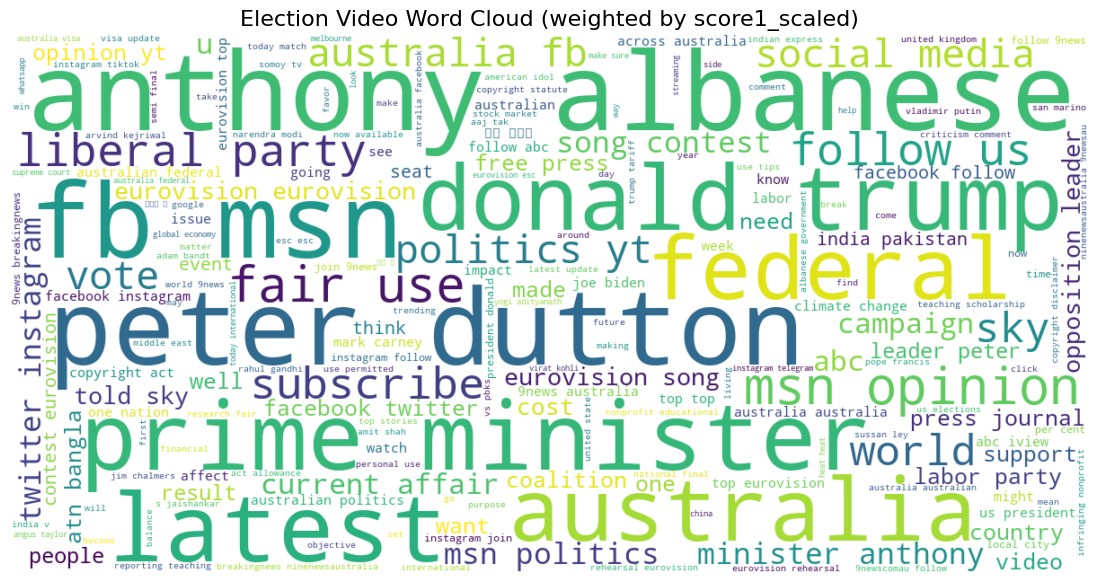

In [14]:
def weighted_text(row, weight_col='score1_scaled'):
    weight = int(row[weight_col] // 10) 
    return (row['clean_text'] + ' ') * max(1, weight)

yte_df['weighted_text'] = yte_df.apply(weighted_text, axis=1)
combined_text = ' '.join(yte_df['weighted_text'])
from wordcloud import WordCloud
import matplotlib.pyplot as plt

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'live', 'youtube', 'new', 'shorts', 'channel', 
    'election', 'news', 'breaking'           
])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=200
).generate(combined_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Election Video Word Cloud (weighted by score1_scaled)", fontsize=16)
plt.show()


In [21]:
from wordcloud import WordCloud, STOPWORDS

def plot_wordcloud(df, title, weight_col='score1_scaled'):
    # Define how to weight each row’s text
    def weighted_text(row):
        weight = int(row[weight_col] // 10)
        return (row['clean_text'] + ' ') * max(1, weight)

    df = df.copy()
    df['weighted_text'] = df.apply(weighted_text, axis=1)
    combined_text = ' '.join(df['weighted_text'])

    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update([
        'live', 'youtube', 'new', 'shorts', 'channel', 
         'news', 'breaking'           
    ])

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=custom_stopwords,
        max_words=200
    ).generate(combined_text)

    plt.figure(figsize=(14, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()


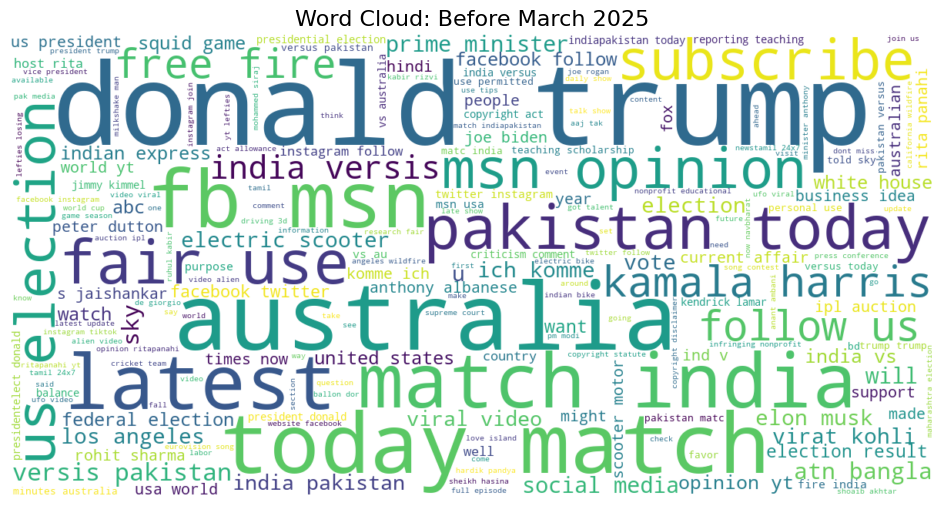

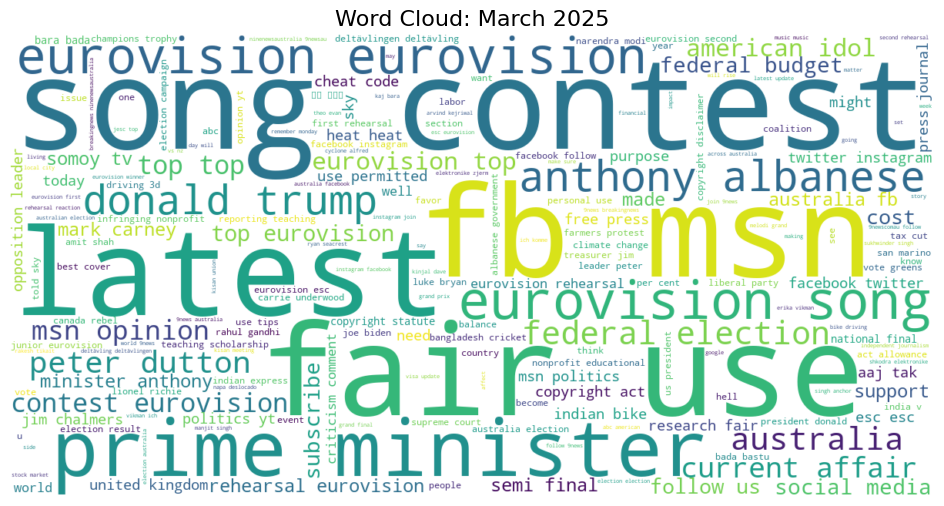

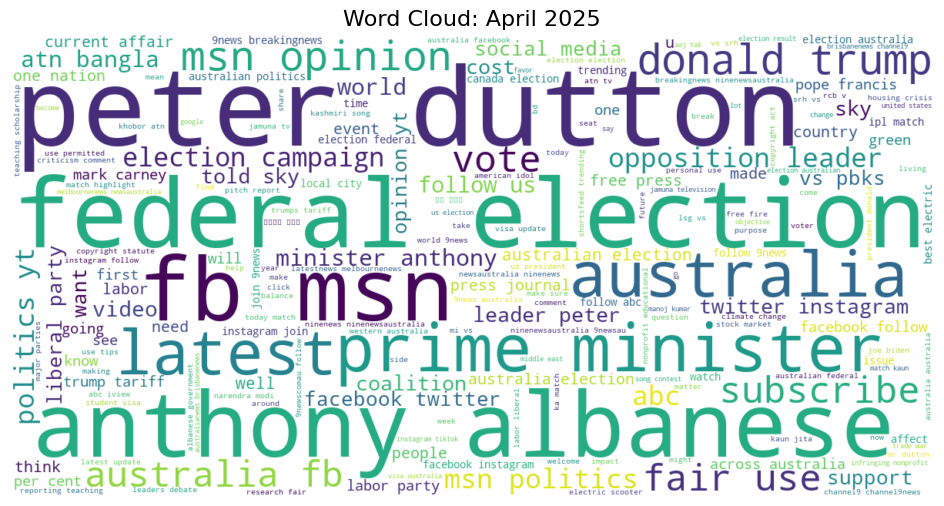

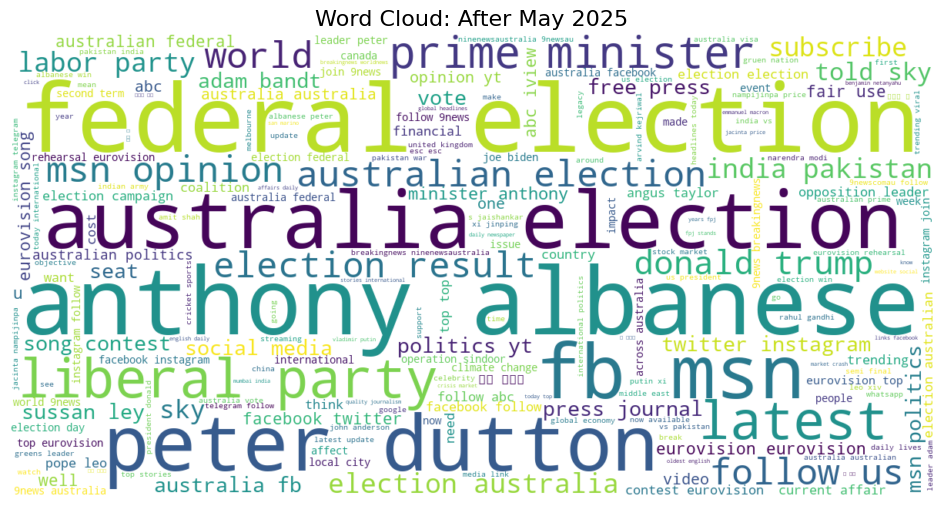

In [22]:
# 时间节点定义
march_cutoff = pd.Timestamp("2025-03-01", tz="Australia/Melbourne")
april_start = pd.Timestamp("2025-04-01", tz="Australia/Melbourne")
may_start = pd.Timestamp("2025-05-01", tz="Australia/Melbourne")

# 四个区间
before_march = yte_df[yte_df['published_melbourne'] < march_cutoff]
march_only = yte_df[(yte_df['published_melbourne'] >= march_cutoff) & (yte_df['published_melbourne'] < april_start)]
april_only = yte_df[(yte_df['published_melbourne'] >= april_start) & (yte_df['published_melbourne'] < may_start)]
after_may = yte_df[yte_df['published_melbourne'] >= may_start]

# 画图（每段画一个词云）
plot_wordcloud(before_march, "Word Cloud: Before March 2025")
plot_wordcloud(march_only, "Word Cloud: March 2025")
plot_wordcloud(april_only, "Word Cloud: April 2025")
plot_wordcloud(after_may, "Word Cloud: After May 2025")